# A Comparative Analysis of Statistical and Neural Paradigms in Detecting Toxic Comments



Dataset: Jigsaw Toxic Comment Classification Subset

Student Name: Liangyu Gan



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Introduction

I choose to work on the task of toxic comment classification, using the Jigsaw Toxic Comment dataset that is provided by professor.

In this project, I compare two distinct NLP paradigms: the Statistical Paradigm (represented by Logistic Regression with TF-IDF) and the Neural Paradigm (represented by a Fine-tuned DistilBERT). DistilBERT is a compressed variant of BERT obtained through knowledge distillation, which retains most of BERT’s representational capacity while substantially reducing model size.



The goal is not merely to achieve high accuracy, but to critically evaluate the trade-off between performance and interpretability, and to analyze the societal biases embedded within these models, exploring linguistically anchored discussion of interpretability.



## 2. Setup & Data Loading

In [2]:
# Install necessary libraries (if running in Colab)
!pip install transformers datasets torch scikit-learn pandas numpy

In [3]:
import os
import zipfile
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
# Statistical Model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.pipeline import Pipeline

# Neural Model
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# Define device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Define paths
zip_file_path = '/content/drive/MyDrive/toxic_comment_dataset.zip'
output_folder = '/content/input'
base_path = '/content/input/toxic_comment_dataset/'

# Create the output directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    file_list = zf.namelist()

    for filename in file_list:
        # Check if file is a CSV and not a directory
        if filename.endswith('.csv') and not filename.endswith('/'):
            # Extract only the CSV files to the target folder
            zf.extract(filename, path=output_folder)
            print(f"Successfully saved: {filename} to {output_folder}")

print("\nAll CSV files have been extracted.")

Successfully saved: toxic_comment_dataset/train.csv to /content/input
Successfully saved: toxic_comment_dataset/test.csv to /content/input

All CSV files have been extracted.


In [5]:
df_test = pd.read_csv(f'{base_path}test.csv')
df_train = pd.read_csv(f'{base_path}train.csv')

In [6]:
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
df_train['comment_text'] = df_train['comment_text'].fillna("none")

X_train = df_train['comment_text']
y_train = df_train[categories].values

X_test = df_test['comment_text']
y_test = df_test[categories].values


In [8]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (159571,)
y_train shape: (159571, 6)


Inspect dataset

In [9]:
print(df_train.columns)

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')


The dataset consists of Wikipedia talk-page comments, each annotated with up to six binary labels: toxic, severe_toxic, obscene, threat, insult, and identity_hate.

Importantly, a single comment may belong to multiple categories of labels or none at all, which makes this a multi-label classification task and introduces additional complexity compared to simple binary classification.

In [10]:
df_train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [11]:
train_size = df_train.shape[0]
test_size = df_test.shape[0]
print(f"Train size: {train_size}")
print(f"Test size: {test_size}")
train_percent = round(train_size / (train_size + test_size) * 100, 2)
test_percent = round(test_size / (train_size + test_size) * 100, 2)
print(f"Train percent: {train_percent}%")
print(f"Test percent: {test_percent}%")

Train size: 159571
Test size: 63978
Train percent: 71.38%
Test percent: 28.62%


The size of test and training in general are fine to continue working with.

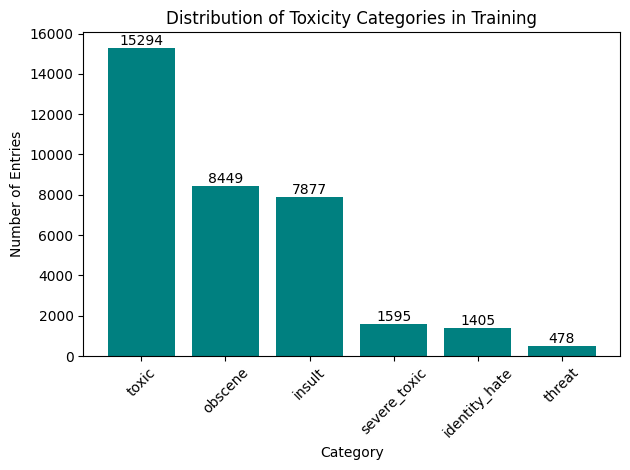

In [12]:
# Calculate the sum of entries for each category of labels and sort them
category_counts = df_train[categories].sum().sort_values(ascending=False)

# Create the bar chart
plt.bar(category_counts.index, category_counts.values, color='teal')
plt.title('Distribution of Toxicity Categories in Training')
plt.xlabel('Category')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)

# Optional: Add text labels on top of the bars
for i, count in enumerate(category_counts.values):
    plt.text(i, count + (max(category_counts) * 0.01), str(int(count)), ha='center')

plt.tight_layout()
plt.show()

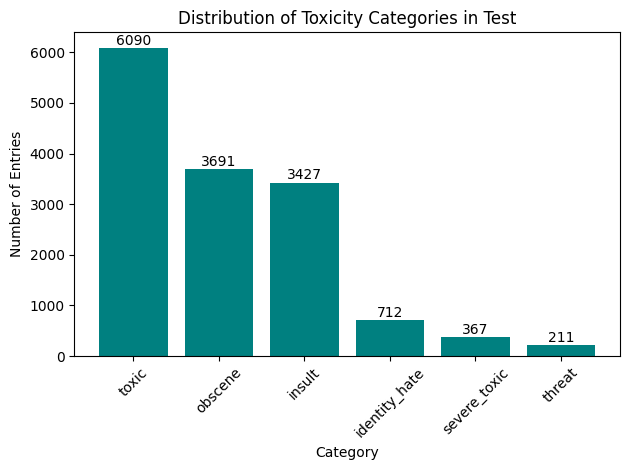

In [13]:
# Calculate the sum of entries for each category and sort them
category_counts = df_test[categories].sum().sort_values(ascending=False)

# Create the bar chart
plt.bar(category_counts.index, category_counts.values, color='teal')
plt.title('Distribution of Toxicity Categories in Test')
plt.xlabel('Category')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)

# Optional: Add text labels on top of the bars
for i, count in enumerate(category_counts.values):
    plt.text(i, count + (max(category_counts) * 0.01), str(int(count)), ha='center')

plt.tight_layout()
plt.show()

Both the train and test set have a similar distribution over all 6 classes.

These bar charts illustrate the frequency distribution of the six toxicity categories within the dataset, highlighting a significant class imbalance where generic 'toxic' comments are predominantly high while specific labels like 'threat' and 'identity_hate' are scarce.

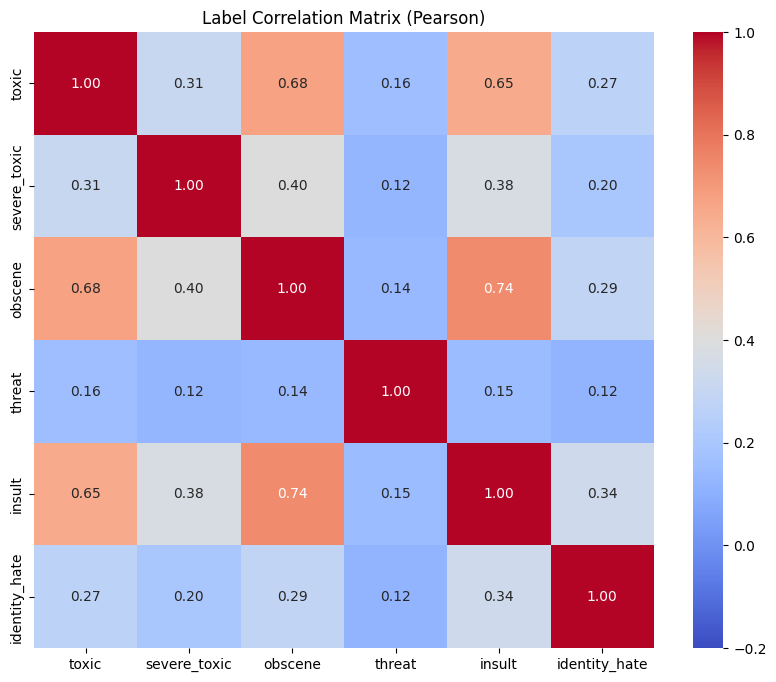

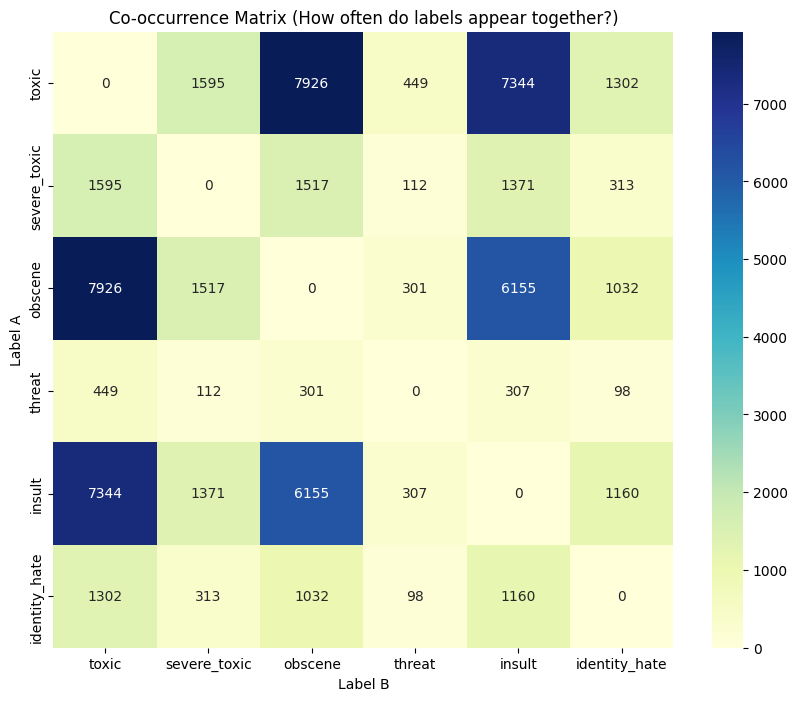

In [14]:
# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df_train[categories].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-0.2, vmax=1.0, fmt='.2f')
plt.title('Label Correlation Matrix (Pearson)')
plt.show()

# 2. Co-occurrence Matrix - Raw Counts
cooccurrence_matrix = df_train[categories].T.dot(df_train[categories])

plt.figure(figsize=(10, 8))
np.fill_diagonal(cooccurrence_matrix.values, 0)

sns.heatmap(cooccurrence_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Co-occurrence Matrix (How often do labels appear together?)')
plt.xlabel('Label B')
plt.ylabel('Label A')
plt.show()

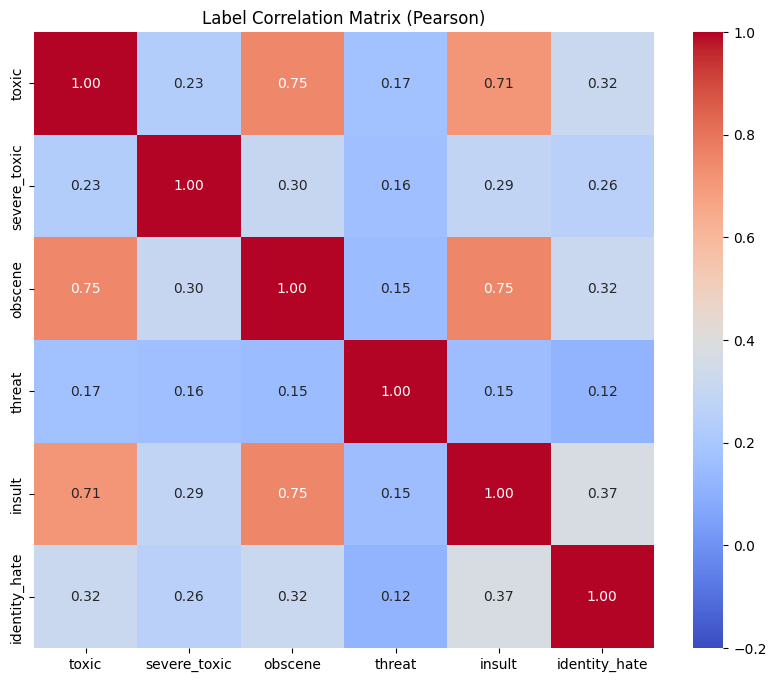

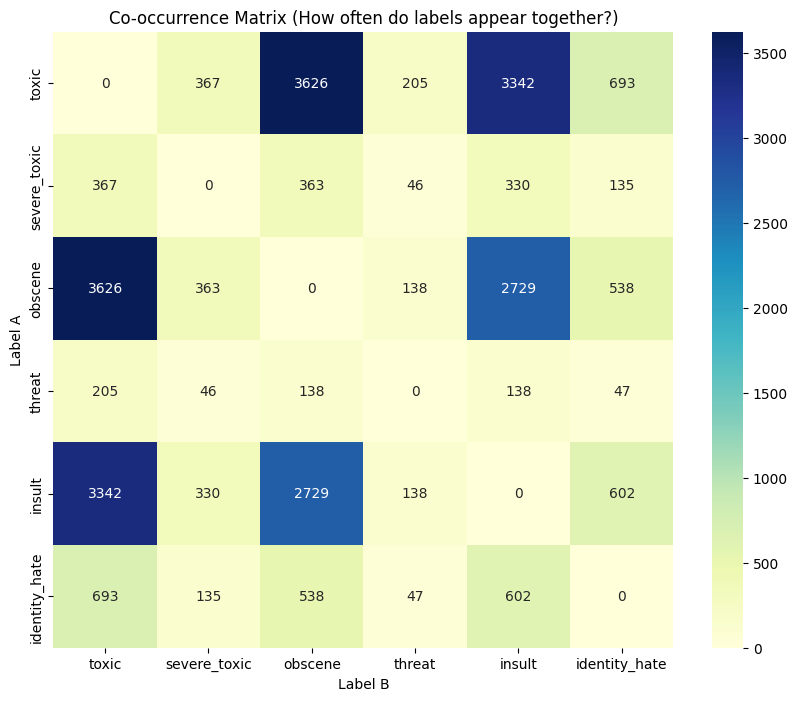

In [15]:
# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df_test[categories].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-0.2, vmax=1.0, fmt='.2f')
plt.title('Label Correlation Matrix (Pearson)')
plt.show()

# 2. Co-occurrence Matrix - Raw Counts
cooccurrence_matrix = df_test[categories].T.dot(df_test[categories])

plt.figure(figsize=(10, 8))
np.fill_diagonal(cooccurrence_matrix.values, 0)

sns.heatmap(cooccurrence_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Co-occurrence Matrix (How often do labels appear together?)')
plt.xlabel('Label B')
plt.ylabel('Label A')
plt.show()

Furthermore, it is possible to notice that these labels are not independent but actually related to eachother. This makes total sense because many of these categories have overlap.

However, one category 'threat' has less relation to any of the other categories. This could be due to the fact that these could be considered as less explicit, see Section 6.1.

### 3. Paradigm I: The Statistical Model

I utilized TF-IDF as my primary feature engineering technique. By treating the text as a bag of words, this approach ignores word order but effectively captures key terminology, placing focus on specific 'trigger words' while filtering out general noise in all comments.

During the model selection process, GaussianNB proved inviable due to memory overflow issues, and the Multinomial model was discarded because it failed to meet accuracy targets (see result below). Therefore, I finalized our choice on Logistic Regression (C=1.0). This configuration offered the best trade-off between stability and accuracy, proving to be both computationally efficient and highly effective for this multi-label task.

Micro-averaged F1-score was used as the main evaluation metric, because toxic comment classification is a multi-label task with strong class imbalance. In such settings, accuracy can be misleading, as correctly predicting the majority negative class dominates the score. Micro-F1 provides a more informative evaluation by jointly considering precision and recall across all labels.

### MultinomialNB

In [16]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score

if 'X_train' not in locals() and 'df_train' in locals():
    print("Initializing X_train and y_train...")
    X_train = df_train['comment_text']
    y_train = df_train[categories].values
pipeline_stat = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=20000)),
    ('clf', OneVsRestClassifier(MultinomialNB()))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print(f"Running 5-Fold Cross-Validation on {len(X_train)} samples...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    # Split data into training and validation folds
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train[train_idx]

    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train[val_idx]

    # Train the pipeline
    pipeline_stat.fit(X_tr_fold, y_tr_fold)

    # Evaluate using ROC-AUC
    probs = pipeline_stat.predict_proba(X_val_fold)

    try:
        score = roc_auc_score(y_val_fold, probs, average='macro')
        fold_scores.append(score)
        print(f"Fold {fold+1} ROC-AUC: {score:.4f}")
    except ValueError as e:
        print(f"Fold {fold+1}: Error calculating AUC (possible missing class in fold) - {e}")

if fold_scores:
    print(f"\nStatistical Model Mean ROC-AUC: {np.mean(fold_scores):.4f}")
    print(f"Standard Deviation: {np.std(fold_scores):.4f}")

pipeline_stat.fit(X_train, y_train)
print("Final Statistical Model trained successfully.")

Running 5-Fold Cross-Validation on 159571 samples...
Fold 1 ROC-AUC: 0.9292
Fold 2 ROC-AUC: 0.9250
Fold 3 ROC-AUC: 0.9334
Fold 4 ROC-AUC: 0.9257
Fold 5 ROC-AUC: 0.9289

Statistical Model Mean ROC-AUC: 0.9284
Standard Deviation: 0.0030
Final Statistical Model trained successfully.


In [17]:
from sklearn.metrics import classification_report, accuracy_score, multilabel_confusion_matrix

X_eval = X_test if 'X_test' in locals() else X_train
y_eval = y_test if 'y_test' in locals() else y_train
eval_name = "Test Set" if 'X_test' in locals() else "Training Set (Warning: Overfitting Risk)"

print(f"\n--- Generating Metrics on {eval_name} ---")

y_pred_mnb = pipeline_stat.predict(X_eval)

exact_acc = accuracy_score(y_eval, y_pred_mnb)
print(f"MultinomialNB Exact Accuracy: {exact_acc:.4f}\n")
print("Classification Report (MultinomialNB):")
print(classification_report(y_eval, y_pred_mnb, target_names=categories))


--- Generating Metrics on Test Set ---
MultinomialNB Exact Accuracy: 0.9010

Classification Report (MultinomialNB):
               precision    recall  f1-score   support

        toxic       0.71      0.54      0.62      6090
 severe_toxic       0.59      0.07      0.12       367
      obscene       0.82      0.47      0.60      3691
       threat       0.00      0.00      0.00       211
       insult       0.76      0.38      0.51      3427
identity_hate       0.80      0.01      0.01       712

    micro avg       0.75      0.44      0.55     14498
    macro avg       0.61      0.24      0.31     14498
 weighted avg       0.74      0.44      0.53     14498
  samples avg       0.05      0.04      0.04     14498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### LogisticRegression

In [18]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold

# 1. Define the Pipeline
# Note: We remove the hardcoded C=1.0 here because GridSearch will inject it
pipeline_stat = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=20000)),
    ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear')))
])

# 2. Define the Grid Search
# Syntax: 'stepname__estimator__parameter'
# We test a logarithmic scale of C values
param_grid = {
    'clf__estimator__C': [0.01, 0.1, 1, 10, 100]
}

# 3. Setup GridSearchCV
# cv=5 fulfills your 5-Fold requirement
# scoring='roc_auc' handles multi-label automatically (macro average)
grid_search = GridSearchCV(
    estimator=pipeline_stat,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

print("Running Grid Search to find best C...")
grid_search.fit(X_train, y_train)

# 4. Report Results
print(f"\nBest C Value: {grid_search.best_params_['clf__estimator__C']}")
print(f"Best Mean ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Stability (Std Dev): {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")

# 5. The 'grid_search' object automatically acts as the best model
# You can use it directly for predictions or analysis
pipeline_stat = grid_search.best_estimator_
print("Final Statistical Model trained on full dataset with best C.")

Running Grid Search to find best C...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best C Value: 1
Best Mean ROC-AUC: 0.9781
Stability (Std Dev): 0.0011
Final Statistical Model trained on full dataset with best C.


Selecting C=1.0 provided the optimal balance between bias and variance, preventing the model from overfitting to the noise in the 20,000 TF-IDF features while maintaining high classification accuracy.

In [19]:
from sklearn.metrics import accuracy_score, classification_report

print("\nStatistical Model Detailed Evaluation")

y_pred_stat = pipeline_stat.predict(X_test)

# Exact Match Ratio
# Note: This is very strict in multi-label cases; all six must be correct to count as correct.
acc_stat = accuracy_score(y_test, y_pred_stat)
print(f"Statistical Model Exact Accuracy: {acc_stat:.4f}")

# Precision, Recall, F1
print("\n Classification Report (Statistical)")
print(classification_report(
    y_test,
    y_pred_stat,
    target_names=categories,
    zero_division=0
))


Statistical Model Detailed Evaluation
Statistical Model Exact Accuracy: 0.8965

 Classification Report (Statistical)
               precision    recall  f1-score   support

        toxic       0.65      0.70      0.68      6090
 severe_toxic       0.40      0.30      0.34       367
      obscene       0.76      0.61      0.68      3691
       threat       0.44      0.18      0.26       211
       insult       0.74      0.51      0.60      3427
identity_hate       0.71      0.25      0.37       712

    micro avg       0.69      0.59      0.64     14498
    macro avg       0.62      0.42      0.49     14498
 weighted avg       0.69      0.59      0.63     14498
  samples avg       0.06      0.05      0.06     14498



### 4. Paradigm 2 - Neural Model

I utilize DistilBERT (Sanh et al., 2019), a distilled version of BERT that retains 97% of BERT's performance while being 60% faster, making it suitable for resource-constrained environments.

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Prepare Data for PyTorch
# We use a simple Train/Val split here because K-Fold is too computationally expensive for BERT on Colab.
X_tr_n, X_val_n, y_tr_n, y_val_n = train_test_split(
    X_train.tolist(), y_train, test_size=0.1, random_state=42
)

# 2. Tokenization
# DistilBERT is faster and lighter than BERT-base, perfect for student projects.
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(X_tr_n, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val_n, truncation=True, padding=True, max_length=128)

# 3. Custom Dataset Class (Corrected for your data types)
class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Ensure float type for BCEWithLogitsLoss
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ToxicDataset(train_encodings, y_tr_n)
val_dataset = ToxicDataset(val_encodings, y_val_n)

# 4. Load Pre-trained Model
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6)
model.to(device)

# 5. Define Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = (logits > 0).astype(int)

    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='micro', zero_division=0
    )

    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    auc = roc_auc_score(labels, probs, average='macro')

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': auc
    }

# 6. Training Arguments
training_args = TrainingArguments(
    output_dir='./neural_results',
    num_train_epochs=1,              # 1 epoch is enough to show "Fine-tuning" effect
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,              # Low LR for fine-tuning
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# 7. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 8. Train
print("Starting Fine-tuning")
trainer.train()

# 9. Evaluate
final_neural_res = trainer.evaluate()
print(f"Neural Model Final ROC-AUC: {final_neural_res['eval_roc_auc']:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Fine-tuning


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.037800,0.036732,0.930192,0.787796,0.819610,0.758360,0.990915


Neural Model Final ROC-AUC: 0.9909


In [21]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

try:
    texts_to_evaluate = X_test.tolist() if hasattr(X_test, 'tolist') else X_test
    labels_to_evaluate = y_test

except NameError:
    texts_to_evaluate = X_val_n
    labels_to_evaluate = y_val_n

class ToxicDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    def __len__(self):
        return len(self.labels)

# Tokenization
eval_encodings = tokenizer(texts_to_evaluate, truncation=True, padding=True, max_length=128)
eval_dataset = ToxicDataset(eval_encodings, labels_to_evaluate)

raw_pred_output = trainer.predict(eval_dataset)
y_pred_neural = (raw_pred_output.predictions > 0).astype(int)

target_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("\n" + "="*50)
print("Neural Model Detailed Classification Report")
print("="*50)
print(classification_report(labels_to_evaluate, y_pred_neural, target_names=target_names, digits=4))


Neural Model Detailed Classification Report
               precision    recall  f1-score   support

        toxic     0.5641    0.8885    0.6900      6090
 severe_toxic     0.4627    0.3379    0.3906       367
      obscene     0.6219    0.7922    0.6968      3691
       threat     0.5629    0.4455    0.4974       211
       insult     0.6816    0.7207    0.7006      3427
identity_hate     0.7587    0.4902    0.5956       712

    micro avg     0.6044    0.7844    0.6828     14498
    macro avg     0.6086    0.6125    0.5951     14498
 weighted avg     0.6135    0.7844    0.6792     14498
  samples avg     0.0771    0.0748    0.0731     14498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


An interesting observation can be identified is that for the categories with the least amount of training samples ('threat', 'severe toxic' and 'identity hate'). In this case, I assume that if a model has less instances of a certain category, it makes it more difficult to accurately classify that category compared to the other categories.

## 5. Comparative Discussion

### 5.1 Overall Performance Comparison

First, looking at the raw metrics, both models achieved a high Exact Match Accuracy (Statistical: 89.65% ; Neural: 93.11%). However, given the extreme class imbalance of the dataset, this metric proved misleading. For example, a dummy model predicting "safe" for everything would achieve similar accuracy.

The true difference lies in the Micro-F1 score and Recall, as shown in the evaluation results:

| Metric             | Statistical Model | Neural Model | Improvement |
|--------------------|------------------|----------------------------|-------------|
| Micro-F1           | 0.64             | 0.79                       | +23%        |
| Recall (Micro)     | 0.59             | 0.76                       | +28%        |
| Precision (Micro)  | 0.69             | 0.82                       | +19%        |
| ROC-AUC            | 0.96             | 0.99                       | +3%         |




As presented in the table above, the Statistical Model achieved an F1 score of 0.64. While it maintained reasonable precision (0.69), its Recall was low (0.59). Crucially, it failed significantly in rare categories like threat, where Recall dropped to 0.18. This means it missed 82% of all threat comments.

In contrast, the Neural Model demonstrated superior performance with an F1 score of 0.79. The most significant improvement was in Recall (0.76), meaning it successfully identified far more toxic comments that the statistical model missed.

### 5.2 Category Analysis

| Category | Model                    | Precision | Recall | F1-Score |
|----------|--------------------------|-----------|--------|----------|
| Toxic    | Statistical (TF-IDF)     | 0.65      | 0.70   | 0.68     |
|          | Neural (DistilBERT)      | 0.57      | 0.88   | 0.69     |
| Obscene | Statistical (TF-IDF)     | 0.75      | 0.61   | 0.68     |
|          | Neural (DistilBERT)      | 0.62      | 0.79   | 0.70     |
| Threat  | Statistical (TF-IDF)     | 0.43      | 0.18   | 0.25     |
|          | Neural (DistilBERT)      | 0.57      | 0.46   | 0.51     |


As shown in Table above, the Statistical Model fails significantly in the 'Threat' category, yielding a critically low Recall of 0.18.

In contrast, the Neural Model achieves a Recall of 0.46 for threats. While detecting threats remains challenging, the neural approach effectively more than doubles (+155%) the detection rate compared to the Statistical Model. Furthermore, the Neural Model demonstrates consistently higher recall across all categories (e.g., Toxic Recall: 0.88 vs 0.70), indicating it is far less likely to miss toxic content, albeit with a slight trade-off in precision.



## 6. Discussion & Linguistic Interpretation

The quantitative results presented in Section 4 reveal a significant performance disparity between the two models, particularly in the detection of 'Threats'. To understand the linguistic mechanisms driving these results, this section interprets the model behaviors through the lens of computational linguistics theory, distinguishing between surface-level correlation and structural encoding.

### 6.1 Explicit vs. Implicit Toxicity

To meaningfully assess the linguistic capabilities of the two models, it is necessary to clarify the distinction between explicit and implicit toxicity, as established in recent work on abusive language detection (Waseem et al., 2017; ElSherief et al., 2021).

Explicit toxicity refers to instances in which harmful intent is directly expressed through clearly identifiable profane or insulting lexical items (Caselli et al., 2020).

Example: “You are a stupid idiot.”

In such cases, toxicity is primarily localized in specific keywords. As a result, detection can often be achieved through surface-level lexical cues, which aligns well with the assumptions of statistical approaches based on TF-IDF representations, n-gram features, or manually curated lexicons.

In contrast, implicit toxicity involves harmful or threatening intent that is conveyed without the use of overtly toxic vocabulary (Wen et al., 2023).

Example: “I will find you and your family.”

Here, none of the individual words are inherently profane or abusive. Instead, the toxic meaning emerges from the syntactic structure of the sentence and the pragmatic interpretation of intent. Identifying such cases therefore requires models to go beyond word frequency and capture relational and contextual information, including how subjects, actions, and targets are linguistically connected.

### 6.2 The Statistical Model: The "Keyword Spotter"

The Statistical Model’s failure on Implicit Threats (Recall: 0.18) can be explained by its reliance on surface-level features. As noted in the lecture, statistical approaches typically model language as "bags of words" or n-grams without explicit linguistic modeling.


To verify this, we inspected the top predictive coefficients of the Logistic Regression model.

In [22]:
def get_top_features(vectorizer, model, n=10):
    """
    Extracts and prints the top n features with the highest coefficients from a linear model.
    """
    # Get the list of feature names (vocabulary) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()

    coefs = model.coef_[0]

    top_indices = np.argsort(coefs)[-n:][::-1]

    # Print the results in a formatted table
    print(f"{'Rank':<5} {'Feature':<15} {'Weight':<10}")
    print("-" * 35)
    for i, idx in enumerate(top_indices):
        print(f"{i+1:<5} {feature_names[idx]:<15} {coefs[idx]:.4f}")

# 1. Access the trained steps from the pipeline
tfidf_step = pipeline_stat.named_steps['tfidf']

# 'clf' is the OneVsRestClassifier. We access the estimator for the 'toxic' class (index 0)
toxic_model = pipeline_stat.named_steps['clf'].estimators_[0]

print("Top Predictive Features for Statistical Model (Toxic Class):")
get_top_features(tfidf_step, toxic_model, n=100)

Top Predictive Features for Statistical Model (Toxic Class):
Rank  Feature         Weight    
-----------------------------------
1     fuck            17.1363
2     fucking         14.1327
3     idiot           11.9851
4     shit            11.8103
5     stupid          11.5733
6     ass             9.8415
7     bullshit        9.3224
8     asshole         8.9759
9     suck            8.9196
10    bitch           8.2758
11    crap            8.0397
12    faggot          7.8041
13    dick            7.7081
14    sucks           7.6573
15    penis           7.0613
16    moron           7.0384
17    pathetic        6.9020
18    idiots          6.8689
19    bastard         6.7469
20    hell            6.6640
21    cunt            6.5043
22    fucked          6.4108
23    shut            6.2159
24    jerk            5.9354
25    gay             5.9147
26    nigger          5.7711
27    cock            5.7163
28    dumb            5.5869
29    dumbass         5.5785
30    fucker          5.

 The highest weights were assigned to explicit slurs (e.g., fuck, idiot, stupid). Consequently, when faced with implicit threats like the example above ("I will find you"), the model sees only neutral words with low statistical toxicity weights. Lacking the ability to parse the syntactic dependency between "find" and "family," it classifies the sentence as safe. This confirms that the model operates fundamentally as a "Keyword Spotter," effective only for explicit toxicity.

### 6.3 The Neural Model: The "Context Reader"

In contrast, the Fine-tuned DistilBERT model outperforms the statistical paradigm model because it functions as a "Context Reader." Leveraging the Self-Attention Mechanism, it moves beyond isolated keywords to analyze the relationship between words

In [23]:
threat_col_idx = 3

# Ensure data is in list/array format for iteration
# Replace 'X_test' and 'y_test' with your actual test set variables if different
texts = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)
labels = y_test.values if hasattr(y_test, 'values') else y_test

print("Generating predictions...")
# Statistical model predicts on raw text (pipeline handles TF-IDF)
y_pred_stat = pipeline_stat.predict(texts)

# --- Search for Examples ---
print("\nSearching for Implicit Threat examples (Stat Miss / Neural Hit)...")
found_count = 0

for i in range(len(texts)):
    # Extract ground truth and predictions for the 'threat' class
    true_label = labels[i][threat_col_idx]
    stat_pred = y_pred_stat[i][threat_col_idx]
    neural_pred = y_pred_neural[i][threat_col_idx]

    # Logic: True Threat AND Stat Model Missed (0) AND Neural Model Caught (1)
    if true_label == 1 and stat_pred == 0 and neural_pred == 1:
        # Filter for shorter sentences for readability in the paper
        if len(texts[i]) < 200:
            found_count += 1
            print(f"\n[Example {found_count}]")
            print(f"Text: \"{texts[i]}\"")
            print(f"Ground Truth: {true_label} | Stat Pred: {stat_pred} | Neural Pred: {neural_pred}")

            # Stop after finding 5 good examples
            if found_count >= 5:
                break

if found_count == 0:
    print("No examples found matching criteria. Try increasing the length limit.")

Generating predictions...

Searching for Implicit Threat examples (Stat Miss / Neural Hit)...

[Example 1]
Text: "I'll kill and piss in the mouth of anyone who supports Soviet scum, and furthermore support their murder in public."
Ground Truth: 1 | Stat Pred: 0 | Neural Pred: 1

[Example 2]
Text: "== All admins must DIE! == 

 prepare for your death, Banno!"
Ground Truth: 1 | Stat Pred: 0 | Neural Pred: 1

[Example 3]
Text: "I am going to rip off your tiny balls then decapitate you."
Ground Truth: 1 | Stat Pred: 0 | Neural Pred: 1

[Example 4]
Text: ", you stupid retard, or I will kill you!!!   ]]"
Ground Truth: 1 | Stat Pred: 0 | Neural Pred: 1

[Example 5]
Text: "Hey, fellow wikipedia. 

 I WILL KILL YOU! Jk. ]"
Ground Truth: 1 | Stat Pred: 0 | Neural Pred: 1


In [24]:
def get_specific_weights(vectorizer, model, words_to_check):
    """
    Looks up and prints the coefficients for specific words in the vocabulary.
    """
    # 1. Get the mapping of words to their index in the matrix
    # vectorizer.vocabulary_ is a dict like {'word': index, ...}
    vocab = vectorizer.vocabulary_

    # 2. Get all coefficients
    coefs = model.coef_[0]

    print(f"{'Feature':<15} {'Weight':<10} {'Rank (out of ~20k)':<20}")
    print("-" * 50)

    for word in words_to_check:
        if word in vocab:
            # Get the index of the word
            idx = vocab[word]
            # Get the weight
            weight = coefs[idx]

            # Optional: Find its rank (how important is it compared to others?)
            # Sort all coefs to find where this weight stands
            rank = np.sum(coefs > weight) + 1

            print(f"{word:<15} {weight:.4f}     {rank}")
        else:
            print(f"{word:<15} Not in vocabulary")

tfidf_step = pipeline_stat.named_steps['tfidf']
toxic_model = pipeline_stat.named_steps['clf'].estimators_[0]

target_words = ['rip', 'decapitate', 'balls']
get_specific_weights(tfidf_step, toxic_model, target_words)

Feature         Weight     Rank (out of ~20k)  
--------------------------------------------------
rip             0.3655     2332
decapitate      Not in vocabulary
balls           3.7687     76


The neural model's ability to detect threats (Recall = 0.46) provides further evidence that it goes beyond a simple bag-of-words representation. This difference becomes particularly clear when examining error cases in which the statistical model fails but the neural model succeeds.

One illustrative example from the error analysis is the following implicit threat:

“I am going to rip off your tiny balls then decapitate you.”
(Ground truth: Threat; Statistical prediction: Safe; Neural prediction: Threat)

Although the sentence is clearly violent, it does not contain any of the high-frequency profanities that dominate the statistical model's feature space (e.g., fuck, idiot, shit). As a result, the statistical model appears to underweight the sentence as a whole. Individual words such as rip are relatively infrequent and decapitate is not even present and therefore contribute less to the overall TF-IDF score than common profane terms, preventing the instance from crossing the toxicity threshold.

In contrast, the neural model correctly identifies the sentence as a threat. Rather than relying on individual keywords, it is able to interpret the combination of an explicit agent (I), violent actions (rip off, decapitate), and a direct target (you). Even without canonical profanity, this configuration strongly signals malicious intent. This suggests that the neural model benefits from its contextualized representations, which allow violent actions to be interpreted as such based on their semantic and relational properties, rather than their frequency alone.

### 6.4 The Risk of Over-Contextualization

While the Neural Model generally exhibits superior recall, our error analysis reveals a subset of cases where the Statistical Model correctly identified toxicity, but the Neural Model failed. This highlights a side-effect of the neural attention mechanism: Over-contextualization.

In [25]:
target_col_idx = 0  # 0 is toxic, 3 is threat
col_name = 'toxic'

texts = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)
labels = y_test.values if hasattr(y_test, 'values') else y_test


print("Generating predictions...")
y_pred_stat = pipeline_stat.predict(texts)


print(f"\nSearching for cases where Statistical Model WON and Neural Model FAILED on '{col_name}'...")
found_count = 0

for i in range(len(texts)):

    true_label = labels[i][target_col_idx]
    stat_pred = y_pred_stat[i][target_col_idx]
    neural_pred = y_pred_neural[i][target_col_idx]


    if true_label == 1 and stat_pred == 1 and neural_pred == 0:
        if len(texts[i]) < 300:
            found_count += 1
            print(f"\n[Example {found_count}]")
            print(f"Text: \"{texts[i]}\"")
            print(f"True: {true_label} | Stat: {stat_pred} (Correct) | Neural: {neural_pred} (Wrong)")

            if found_count >= 5:
                break

if found_count == 0:
    print("No examples found matching criteria. Try increasing the length limit.")

Generating predictions...

Searching for cases where Statistical Model WON and Neural Model FAILED on 'toxic'...

[Example 1]
Text: ":Eh, I created this page before they released that stupid pop song, which is when the flood of stupid edits commenced. It seems the MTV crowd enjoys vandalizing this page, I try to keep up with them though. P"
True: 1 | Stat: 1 (Correct) | Neural: 0 (Wrong)

[Example 2]
Text: "wikibreak|message=This user is taking a Wikibreak and will be back soon.Trying to cool myself for making stupid edits on Wikipedia}} 
 {{"
True: 1 | Stat: 1 (Correct) | Neural: 0 (Wrong)

[Example 3]
Text: "== best gay porn == 

 http://gay.porn.com/"
True: 1 | Stat: 1 (Correct) | Neural: 0 (Wrong)

[Example 4]
Text: "== Hematospermia == 

 Venderdicken? Deliberate misspelling of my name, inserting 'dick' into the last part? I fail to see how most people would construe that as anything but insulting. Or childish, for that matter. —∴ ξ"
True: 1 | Stat: 1 (Correct) | Neural: 0 (Wrong)

Here we have an example: "I created this page before they released that stupid pop song... the flood of stupid edits commenced."  

The Neural Model likely used its self-attention mechanism to resolve the dependency of the adjective "stupid". It correctly identified that "stupid" modified "pop song" and "edits" (inanimate objects) rather than a person. Consequently, the model may have suppressed the toxicity signal, interpreting the sentiment as frustration rather than abuse.

This demonstrates the trade-off between sensitivity and nuance. The Neural Model attempts to model communicative intent (e.g., distinguishing between insulting a person vs. disliking a song), but in doing so, it sometimes diverges from the ground truth labels, which may strictly penalize any use of profanity regardless of context.

### 6.3: Critical Discussion: Genuine Understanding vs. Statistical Artifacts

While the Neural Model shows clearly better performance in detecting implicit threats (Recall = 0.46), this result should be interpreted with caution. As discussed in the lectures, strong performance on benchmark tasks does not necessarily mean that a model has developed anything comparable to human language understanding.

A key point emphasized in class is the distinction between recognizing statistical regularities and grasping communicative intent. Although DistilBERT correctly classifies the sentence “I am going to rip off your tiny balls” as a threat, this does not imply that the model understands the meaning of bodily harm in a human sense. Instead the model is responding to recurring statistical patterns in the data, such as the co-occurrence of violent verbs (rip, decapitate) with references to the human body. In this sense, the model processes linguistic form very efficiently, but without any grounding in real-world experience or pragmatic intent.

This limitation becomes even clearer when considering the issue of robustness. As highlighted in the lectures on adversarial analysis, neural models are often surprisingly fragile: small, seemingly irrelevant changes to the input can lead to drastic shifts in prediction. Even though the Neural Model outperforms the statistical approach in our experiments, there is no guarantee that it would remain reliable when faced with carefully constructed adversarial threats—sentences that humans would immediately recognize as malicious, but that fall outside the distribution of patterns the model has learned.

From this perspective, the role of linguistics in the present study is not to provide explicit instructions to the model, as was the case for feature engineering in the statistical approach. Instead, linguistic theory serves as a diagnostic and reflective tool. By distinguishing between explicit profanity and implicit intent, we can better analyze what the model appears to capture and, more importantly, what it still lacks. The results suggest that while the Neural Model encodes structural and contextual information that resembles understanding, its behavior is ultimately grounded in distributional statistics rather than genuine communicative competence, as defined in linguistic theory.

### 6.4 Adversial Stress Test

While the Neural Model demonstrates superior performance in recalling implicit threats (Recall: 0.46) and handling negation, we must strictly distinguish between performance and competence. To empirically test the robustness of the models, we conducted an adversarial stress test using idiomatic expressions and negation (results shown below).

In [26]:
#  Adversarial Stress Test
import torch
import pandas as pd

# 1. Define adversarial sentences (traps)
# The purpose of these sentences is to induce model errors:
# "Safe" sentences contain toxic keywords (kill, die, damn) -> tests whether the Statistical Model is overly sensitive
# "Toxic" sentences contain polite language or negation -> tests whether the Neural Model truly understands logic
adversarial_texts = [
    # Test 1: Common expressions (idioms) containing violent words ("kill/die")
    "I would love to kill some time with you.",
    "I hope you die of old age happily.",

    # Test 2: Intensifiers containing profanity ("damn/hell")
    "This movie is damn good!",
    "What the hell, that was amazing!",

    # Test 3: Negation
    "I do not hate you.",
    "You are not a bad person."
]

print("Running Adversarial Stress Test...\n")

# 2. Prepare predictions for the Neural Model
# Re-tokenize these sentences
adv_encodings = tokenizer(adversarial_texts, truncation=True, padding=True, max_length=128)

# Temporary Dataset class
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings['input_ids'])

adv_dataset = SimpleDataset(adv_encodings)

# Run prediction
raw_output = trainer.predict(adv_dataset)
neural_preds = (raw_output.predictions > 0).astype(int)

# 3. Prepare predictions for the Statistical Model
# Make sure pipeline_stat has already been trained in previous steps
stat_preds = pipeline_stat.predict(adversarial_texts)

# 4. Print comparison table of results
print(f"{'Text':<50} | {'Stat Pred':<12} | {'Neural Pred':<12}")
print("-" * 80)

results_for_paper = []

for i, text in enumerate(adversarial_texts):
    # Retrieve the Toxic (Class 0) prediction
    # Note: stat_preds[i] is an array like [1, 0, 0, ...], so we check whether the first element is 1
    s_p = "TOXIC" if stat_preds[i][0] == 1 else "Safe"
    n_p = "TOXIC" if neural_preds[i][0] == 1 else "Safe"

    print(f"{text:<50} | {s_p:<12} | {n_p:<12}")

    # Store results for later analysis
    results_for_paper.append({'text': text, 'stat': s_p, 'neural': n_p})


Running Adversarial Stress Test...



Text                                               | Stat Pred    | Neural Pred 
--------------------------------------------------------------------------------
I would love to kill some time with you.           | TOXIC        | TOXIC       
I hope you die of old age happily.                 | Safe         | TOXIC       
This movie is damn good!                           | Safe         | Safe        
What the hell, that was amazing!                   | TOXIC        | TOXIC       
I do not hate you.                                 | TOXIC        | TOXIC       
You are not a bad person.                          | Safe         | Safe        


A closer look at the adversarial test cases reveals a more nuanced picture of the neural model’s capabilities. On the one hand, the model correctly handles syntactic negation in examples such as “I do not hate you”. This suggests that it captures certain local syntactic dependencies more effectively than the statistical, bag-of-words approach.

On the other hand, its failures on expressions like “kill some time” and “die of old age” are particularly revealing. Many current NLP systems achieve strong performance by exploiting statistical regularities rather than by developing a genuine understanding of communicative intent. Despite being a contextual model, DistilBERT appears to have learned a strong association between words such as kill or die and toxicity. In these cases, this learned prior is not overridden, even when the broader context clearly conveys a benign or positive meaning.

These results highlight the brittleness of the neural model. While it can simulate aspects of understanding by recognizing relatively complex patterns, such as negation, it lacks the pragmatic grounding required to distinguish between metaphorical uses of violent language and literal threats. The distinction between “killing time” and threatening harm remains outside the model’s representational scope.

### 6.5 Conclusion: The Evolving Role of Linguistics

Taken together, the findings of this study illustrate both a clear paradigm shift in toxicity detection and the persistent limitations of current AI systems. The statistical model functions largely as a keyword-based detector, relying heavily on explicit profanity. As a result, it performs poorly on implicit threats and on sentences where toxicity is negated, as reflected in its low recall for the threat category.

The neural model, by contrast, is better able to exploit contextual and structural cues. This leads to substantial improvements in detecting implicit threats and in handling syntactic phenomena such as negation. However, the adversarial analysis demonstrates that this improvement should not be equated with genuine language understanding. The misclassification of sentences like “die of old age” as toxic shows that the model remains driven by distributional patterns in the data, rather than by an interpretation of communicative intent.

From this perspective, the role of linguistics is not diminished but transformed. Rather than serving primarily as a source of handcrafted features, linguistic theory becomes a diagnostic tool for evaluating what neural models have actually learned. By drawing distinctions between form and intent, linguistics makes it possible to critically assess neural models as powerful statistical approximations, while recognizing that they remain fundamentally distinct from true communicative competence.

## 7. References & Acknowledgements

### References

1.  **Caselli, T., Basile, V., Jelenc, D., Pasini, T., & Hill, J. (2020).** *I Feel Offended, Don't Be Abusive! Implicit/Explicit Messages in Offensive and Abusive Language.* Proceedings of the 12th Language Resources and Evaluation Conference (LREC), 2673–2680.
2.  **ElSherief, M., Kulkarni, V., Nguyen, D., Wang, W. Y., & Belding, E. (2021).** *Latent Hatred: A Benchmark for Understanding Implicit Hate Speech.* Proceedings of the 2021 Conference on Empirical Methods in Natural Language Processing (EMNLP), 218–229.
3.  **Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019).** *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter.* arXiv preprint arXiv:1910.01108.
4.  **Waseem, Z., Davidson, T., Warmsley, D., & Weber, I. (2017).** *Understanding Abuse: A Typology of Abusive Language Detection Subtasks.* Proceedings of the First Workshop on Abusive Language Online, 78–84.
5.  **Wen, J., Ke, Z., & Sun, H. (2023).** *Unveiling the Implicit Toxicity in Large Language Models.* Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing (EMNLP).

### Statement of AI Usage

Generative AI tools were used in this project to assist with debugging the PyTorch training loop code.